In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction,
    
    plot_density,
)

SAMPLERS = {
    "TruncatedGMM": TruncatedGMM,
    "TruncatedNormal": TruncatedNormal,
    "Sinusoidal": Sinusoidal,
    "StepFunction": StepFunction,
}


In [2]:
import json
with open('dpg-name-mapping.json', 'r') as f:
    DGP_NAME_MAPPING = json.load(f)

In [5]:
# Create the 6 DGPs with exact parameters from the paper
def create_dgps():
    """Create all 6 DGPs with the exact parameters used in experiments"""
    
    # 1. Truncated Normal
    tn = TruncatedNormal(mean=0.5, std=0.1, lower=0, upper=1)
    
    # 2. Truncated GMM (symmetric, 3 components)
    gmm_sym = TruncatedGMM(
        components=[
            {'mean': 0.2, 'std': 0.05, 'lower': 0, 'upper': 1},
            {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1},
            {'mean': 0.8, 'std': 0.05, 'lower': 0, 'upper': 1}
        ],
        weights=[0.33, 0.34, 0.33]
    )
    
    # 3. Truncated GMM (asymmetric, 3 components)
    gmm_asym = TruncatedGMM(
        components=[
            {'mean': 0.35, 'std': 0.1, 'lower': 0.0, 'upper': 1.0},
            {'mean': 0.65, 'std': 0.05, 'lower': 0.0, 'upper': 1.0},
            {'mean': 0.9, 'std': 0.2, 'lower': 0.0, 'upper': 1.0}
        ],
        weights=[0.4, 0.4, 0.2]
    )
    
    # 4. Truncated GMM (five spikes + background)
    gmm_spikes = TruncatedGMM(
        components=[
            {'mean': 0.45, 'std': 0.005, 'lower': 0, 'upper': 1},
            {'mean': 0.475, 'std': 0.005, 'lower': 0, 'upper': 1},
            {'mean': 0.5, 'std': 0.005, 'lower': 0, 'upper': 1},
            {'mean': 0.525, 'std': 0.005, 'lower': 0, 'upper': 1},
            {'mean': 0.55, 'std': 0.005, 'lower': 0, 'upper': 1},
            {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1}
        ],
        weights=[1/15, 1/15, 1/15, 1/15, 1/15, 2/3]
    )
    
    # 5. Step Function
    step = StepFunction(level1=1.0, level2=0.5, breakpoint=0.7)
    
    # 6. Sinusoidal
    sin = Sinusoidal()
    
    return {
        'TruncatedNormal': tn,
        'TruncatedGMMSymmetricThree': gmm_sym,
        'TruncatedGMMAsymmetricThree': gmm_asym,
        'TruncatedGMMFiveSpikes': gmm_spikes,
        'StepFunction': step,
        'Sinusoidal': sin
    }

# Create all DGPs
dgps = create_dgps()

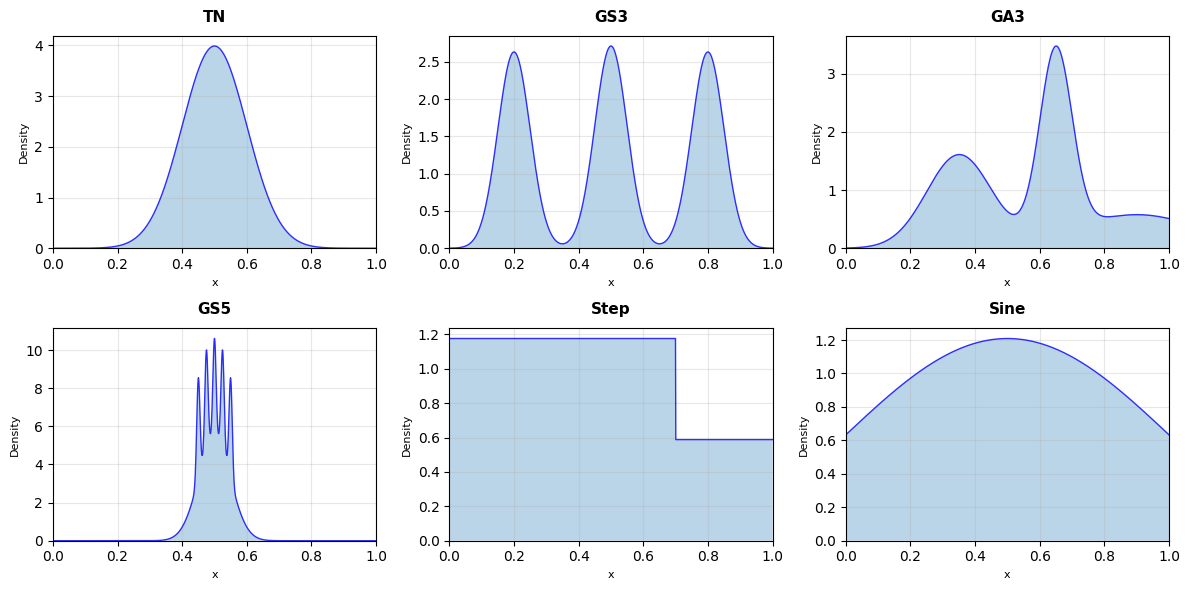

In [6]:
# Plot all 6 DGPs in a 2x3 grid
def plot_all_dgps(dgps, grid_size=1000):
    """Plot all DGPs in a 2x3 subplot layout"""
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))    
    # Create evaluation grid
    x_grid = np.linspace(0, 1, grid_size)
    
    # Plot each DGP
    dgp_names = list(dgps.keys())
    
    for idx, (name, dgp) in enumerate(dgps.items()):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Compute density
        density = dgp.compute_density(x_grid)
        
        # Plot density
        ax.plot(x_grid, density, 'b-', linewidth=1, alpha=0.8)
        ax.fill_between(x_grid, density, alpha=0.3)
        
        # Formatting
        ax.set_title(DGP_NAME_MAPPING[name], fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('x', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        
        # Set y-axis to start from 0
        y_max = np.max(density) * 1.05
        ax.set_ylim(0, y_max)
    
    plt.subplots_adjust(top=0.93)
    plt.tight_layout()
    plt.savefig('paper/resources/simulation_dgp.png', dpi=300)
    return fig

# Create the plot
fig = plot_all_dgps(dgps)
plt.show()